In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from google.colab import files
uploaded = files.upload()
filename=next(iter(uploaded))

df = pd.read_csv(filename)

df.head()

Saving train_df.csv to train_df (2).csv


,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [19]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                5000 non-null   int64 
 1   gender             5000 non-null   object
 2   primary_diagnosis  5000 non-null   object
 3   num_procedures     5000 non-null   int64 
 4   days_in_hospital   5000 non-null   int64 
 5   comorbidity_score  5000 non-null   int64 
 6   discharge_to       5000 non-null   object
 7   readmitted         5000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


,age,num_procedures,days_in_hospital,comorbidity_score,readmitted
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,53.299000,4.46100,7.396600,2.068600,0.188000
std,20.646851,2.88606,4.025587,1.422357,0.390751
min,18.000000,0.00000,1.000000,0.000000,0.000000
25%,36.000000,2.00000,4.000000,1.000000,0.000000
50%,53.000000,4.00000,7.000000,2.000000,0.000000
75%,71.000000,7.00000,11.000000,3.000000,0.000000
max,89.000000,9.00000,14.000000,4.000000,1.000000


In [20]:
df["readmitted"].value_counts()

,count
readmitted,
0,4060
1,940


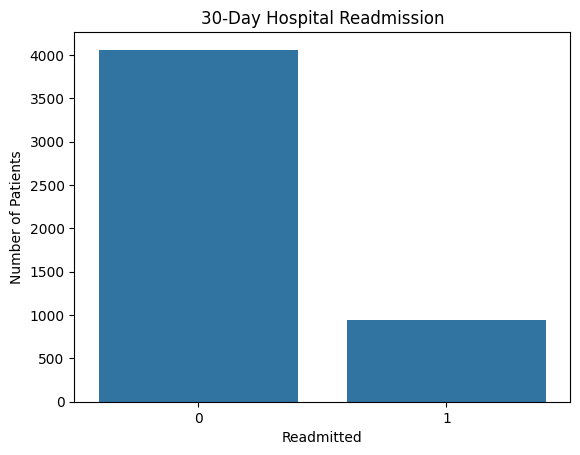

In [21]:
sns.countplot(x="readmitted", data=df)

plt.title("30-Day Hospital Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")

plt.show()

In [22]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

print("Features:")
print(X.columns)

print("Target:")
print(y.name)

Features:
Index(['age', 'gender', 'primary_diagnosis', 'num_procedures',
       'days_in_hospital', 'comorbidity_score', 'discharge_to'],
      dtype='object')
Target:
readmitted


In [23]:
X.isnull().sum()

,0
age,0
gender,0
primary_diagnosis,0
num_procedures,0
days_in_hospital,0
comorbidity_score,0
discharge_to,0


In [24]:
print("Gender:")
print(df["gender"].value_counts())

print("\nDiagnosis:")
print(df["primary_diagnosis"].value_counts())

print("\nDischarge destination:")
print(df["discharge_to"].value_counts())

Gender:
gender
Female    2519
Male      2481
Name: count, dtype: int64

Diagnosis:
primary_diagnosis
Kidney Disease    1035
Diabetes          1017
COPD              1009
Hypertension       978
Heart Disease      961
Name: count, dtype: int64

Discharge destination:
discharge_to
Home                        1306
Home Health Care            1297
Rehabilitation Facility     1221
Skilled Nursing Facility    1176
Name: count, dtype: int64


In [25]:
X_encoded = pd.get_dummies(
    X,
    columns=["gender", "primary_diagnosis", "discharge_to"],
    drop_first=True
)

X_encoded.head()

,age,num_procedures,days_in_hospital,comorbidity_score,gender_Male,primary_diagnosis_Diabetes,primary_diagnosis_Heart Disease,primary_diagnosis_Hypertension,primary_diagnosis_Kidney Disease,discharge_to_Home Health Care,discharge_to_Rehabilitation Facility,discharge_to_Skilled Nursing Facility
0,69,1,2,1,True,False,True,False,False,True,False,False
1,32,2,13,2,False,False,False,False,False,False,True,False
2,89,1,7,1,True,True,False,False,False,False,False,False
3,78,9,2,2,True,False,False,False,False,False,False,True
4,38,6,4,4,True,True,False,False,False,False,True,False


In [26]:
print("Original number of features:", X.shape[1])
print("Encoded number of features:", X_encoded.shape[1])

Original number of features: 7
Encoded number of features: 12


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000
Testing samples: 1000


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [30]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:10])

[0.18898091 0.21007857 0.18024207 0.19798939 0.17562877 0.16197352
 0.19815729 0.18569626 0.19032171 0.18668632]


In [31]:
y_pred = (y_prob >= 0.5).astype(int)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [32]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.507


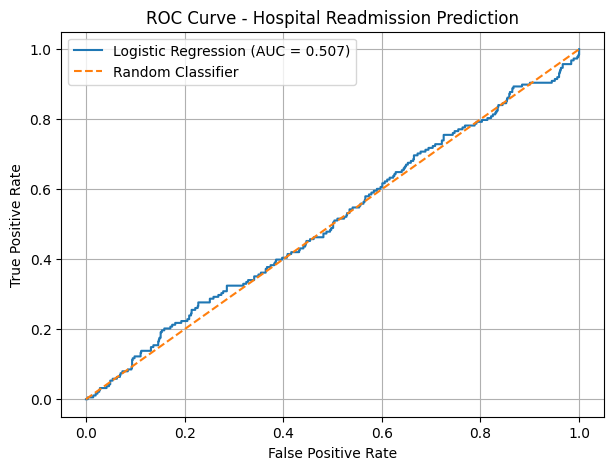

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid()
plt.show()

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[812   0]
 [188   0]]


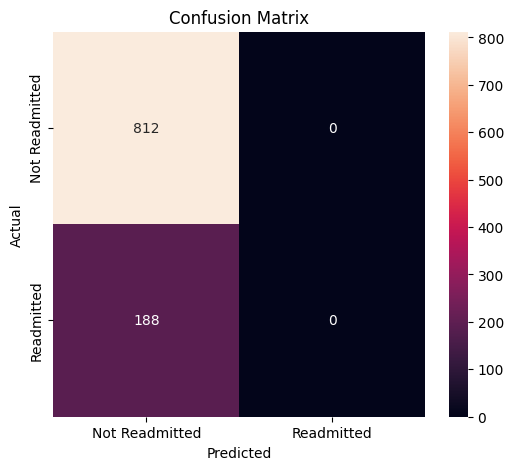

In [35]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90       812
           1       0.00      0.00      0.00       188

    accuracy                           0.81      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.66      0.81      0.73      1000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
from sklearn.metrics import confusion_matrix

thresholds_to_test = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\nThreshold: {threshold}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Recall: {recall:.3f}")


Threshold: 0.5
TN: 812, FP: 0, FN: 188, TP: 0
Recall: 0.000

Threshold: 0.4
TN: 812, FP: 0, FN: 188, TP: 0
Recall: 0.000

Threshold: 0.3
TN: 812, FP: 0, FN: 188, TP: 0
Recall: 0.000

Threshold: 0.2
TN: 635, FP: 177, FN: 140, TP: 48
Recall: 0.255

Threshold: 0.1
TN: 0, FP: 812, FN: 0, TP: 188
Recall: 1.000
